# CASIA Iris V4 - Dataset Collection and Analysis

This notebook performs the initial analysis of the CASIA Iris V4 dataset.

Objectives:
- Inspect the dataset structure
- Count images and identities
- Analyze image properties
- Examine left/right eye distribution
- Visualize sample images
- Prepare the dataset for preprocessing

In [1]:
# Check Python version

import sys

print("Python version:", sys.version)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No NVIDIA GPU detected.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

drive_path = "/content/drive/MyDrive"

print("Drive contents:")
print(os.listdir(drive_path)[:20])

Drive contents:
['24U020025   Pranav Sunil Wagh', 'WhatsApp Image 2025-02-28 at 19.08.07.jpeg', 'WhatsApp Image 2025-02-28 at 19.12.34.jpeg', 'WhatsApp Image 2025-02-28 at 19.13.49.jpeg', 'OD332681329549112100 (1) (1).pdf', 'Screenshot 2025-04-06 at 4.55.39\u202fPM (1).pdf', '59c74ea7-d2c9-416c-b445-90e5fad61941.pdf', 'Screenshot 2025-04-06 at 4.55.39\u202fPM.pdf', 'OD332681329549112100 (1).pdf', 'Screenshot_2025-07-08-16-04-32-04_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Screenshot_2025-07-08-10-40-01-77_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Lab Assignment 1 DBMS.pdf.pdf', 'toaz.info-c-balaguruswamy-pr_448f37de1d55d1847b5a6ccd022f770c.pdf', 'IIIT BPL.pdf', 'Colab Notebooks', 'IMG20251015113500.jpg', 'Screenshot_2025-10-15-19-00-00-13_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Screenshot_2025-10-16-19-19-36-76_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Screenshot_2025-10-16-19-21-57-11_6012fa4d4ddec268fc5c7112cbb265e7.jpg', 'Unit V Recurrence Relations_copy.pdf']


In [5]:
from pathlib import Path

# Main project directory
project_path = Path("/content/drive/MyDrive/Ocular_Project")

# Create project subdirectories
folders = [
    "datasets",
    "models",
    "generated_images",
    "results"
]

for folder in folders:
    (project_path / folder).mkdir(parents=True, exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [6]:
print("Project location:")
print(project_path)

print("\nProject folders:")
for item in project_path.iterdir():
    print("📁", item.name)

Project location:
/content/drive/MyDrive/Ocular_Project

Project folders:
📁 datasets
📁 models
📁 generated_images
📁 results


In [7]:
from pathlib import Path

dataset_folder = Path("/content/drive/MyDrive/Ocular_Project/datasets")

print("Files inside datasets folder:")
for item in dataset_folder.iterdir():
    print(item.name)

Files inside datasets folder:
archive.zip


In [8]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/Ocular_Project/datasets/archive.zip")
extract_path = Path("/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand")

extract_path.mkdir(parents=True, exist_ok=True)

print("Extracting dataset...")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extracting dataset...
Extraction completed!


In [9]:
from pathlib import Path

extract_path = Path("/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand")

print("Contents of extracted dataset:")
for item in extract_path.iterdir():
    print(item.name)

Contents of extracted dataset:
CASIA-Iris-Thousand
iris_thousands.csv


In [10]:
from pathlib import Path

image_folder = Path(
    "/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand"
)

print("Contents of inner folder:")

for item in list(image_folder.iterdir())[:20]:
    print(item.name)

Contents of inner folder:
CASIA-Iris-Thousand


In [11]:
from pathlib import Path

image_folder = Path(
    "/content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand"
)

print("Contents of actual dataset folder:")

for item in list(image_folder.iterdir())[:20]:
    print(item.name)

Contents of actual dataset folder:
000
001
002
003
004
005
006
007
008
009
010
011
012
013
014
015
016
017
018
019


In [12]:
subject_000 = image_folder / "000"

print("Files inside subject 000:")

for item in subject_000.iterdir():
    print(item.name)

Files inside subject 000:
L
R


In [13]:
left_eye = subject_000 / "L"

print("Files inside Subject 000 → Left eye:")

for item in list(left_eye.iterdir())[:20]:
    print(item.name)

Files inside Subject 000 → Left eye:
S5000L00.jpg
S5000L01.jpg
S5000L02.jpg
S5000L03.jpg
S5000L04.jpg
S5000L05.jpg
S5000L06.jpg
S5000L07.jpg
S5000L08.jpg
S5000L09.jpg


Image size: (640, 480)
Image mode: L


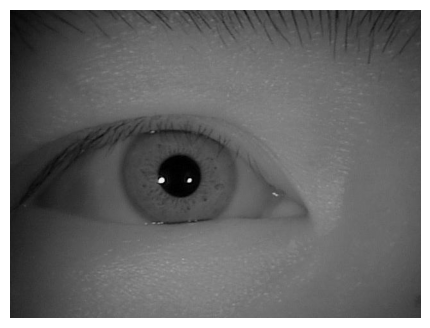

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = left_eye / "S5000L00.jpg"

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(6, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [15]:
# Count subject folders

subjects = [
    item for item in image_folder.iterdir()
    if item.is_dir()
]

print("Number of subjects:", len(subjects))
print("First 10 subjects:")

for subject in subjects[:10]:
    print(subject.name)

Number of subjects: 1000
First 10 subjects:
000
001
002
003
004
005
006
007
008
009


In [16]:
total_images = 0
left_images = 0
right_images = 0

for subject in subjects:
    left_folder = subject / "L"
    right_folder = subject / "R"

    if left_folder.exists():
        count = len(list(left_folder.glob("*.jpg")))
        left_images += count
        total_images += count

    if right_folder.exists():
        count = len(list(right_folder.glob("*.jpg")))
        right_images += count
        total_images += count

print("Total images:", total_images)
print("Left-eye images:", left_images)
print("Right-eye images:", right_images)

Total images: 20000
Left-eye images: 10000
Right-eye images: 10000


In [17]:
subject_image_counts = []

for subject in subjects:
    left_count = len(list((subject / "L").glob("*.jpg")))
    right_count = len(list((subject / "R").glob("*.jpg")))

    subject_image_counts.append((subject.name, left_count, right_count))

print("First 10 subjects:")
for item in subject_image_counts[:10]:
    print(item)

First 10 subjects:
('000', 10, 10)
('001', 10, 10)
('002', 10, 10)
('003', 10, 10)
('004', 10, 10)
('005', 10, 10)
('006', 10, 10)
('007', 10, 10)
('008', 10, 10)
('009', 10, 10)


In [18]:
# Check whether every subject has exactly
# 10 left-eye images and 10 right-eye images

perfect_subjects = 0
problem_subjects = []

for subject, left_count, right_count in subject_image_counts:

    if left_count == 10 and right_count == 10:
        perfect_subjects += 1
    else:
        problem_subjects.append(
            (subject, left_count, right_count)
        )

print("Subjects with 10 left + 10 right:", perfect_subjects)
print("Subjects with different counts:", len(problem_subjects))

if problem_subjects:
    print("\nProblem subjects:")
    for item in problem_subjects[:20]:
        print(item)

Subjects with 10 left + 10 right: 1000
Subjects with different counts: 0


In [19]:
from PIL import Image

# Check a few images from different subjects
sample_images = [
    image_folder / "000" / "L" / "S5000L00.jpg",
    image_folder / "000" / "R" / "S5000R00.jpg",
    image_folder / "100" / "L" / "S5100L00.jpg",
    image_folder / "500" / "R" / "S5500R00.jpg",
    image_folder / "999" / "L" / "S5999L00.jpg"
]

print("Image properties:\n")

for image_path in sample_images:
    img = Image.open(image_path)

    print("File:", image_path.name)
    print("Size:", img.size)
    print("Mode:", img.mode)
    print("Format:", img.format)
    print("-" * 40)

Image properties:

File: S5000L00.jpg
Size: (640, 480)
Mode: L
Format: JPEG
----------------------------------------
File: S5000R00.jpg
Size: (640, 480)
Mode: L
Format: JPEG
----------------------------------------
File: S5100L00.jpg
Size: (640, 480)
Mode: L
Format: JPEG
----------------------------------------
File: S5500R00.jpg
Size: (640, 480)
Mode: L
Format: JPEG
----------------------------------------
File: S5999L00.jpg
Size: (640, 480)
Mode: L
Format: JPEG
----------------------------------------


In [20]:
from PIL import Image

print("Checking all 20,000 images...")

total_checked = 0
corrupted_images = []

for subject in subjects:
    for eye in ["L", "R"]:
        eye_folder = subject / eye

        for image_path in eye_folder.glob("*.jpg"):
            total_checked += 1

            try:
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted_images.append(str(image_path))

print("\nTotal images checked:", total_checked)
print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nFirst few corrupted images:")
    for path in corrupted_images[:10]:
        print(path)

Checking all 20,000 images...

Total images checked: 20000
Corrupted images: 0


In [21]:
import numpy as np
from PIL import Image

print("Pixel statistics:\n")

for image_path in sample_images:

    img = np.array(Image.open(image_path))

    print("File:", image_path.name)
    print("Minimum pixel value:", img.min())
    print("Maximum pixel value:", img.max())
    print("Mean pixel value:", round(img.mean(), 2))
    print("Standard deviation:", round(img.std(), 2))
    print("-" * 40)

Pixel statistics:

File: S5000L00.jpg
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 92.16
Standard deviation: 29.06
----------------------------------------
File: S5000R00.jpg
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 90.28
Standard deviation: 29.23
----------------------------------------
File: S5100L00.jpg
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 90.26
Standard deviation: 34.13
----------------------------------------
File: S5500R00.jpg
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 92.29
Standard deviation: 31.83
----------------------------------------
File: S5999L00.jpg
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 93.07
Standard deviation: 32.07
----------------------------------------


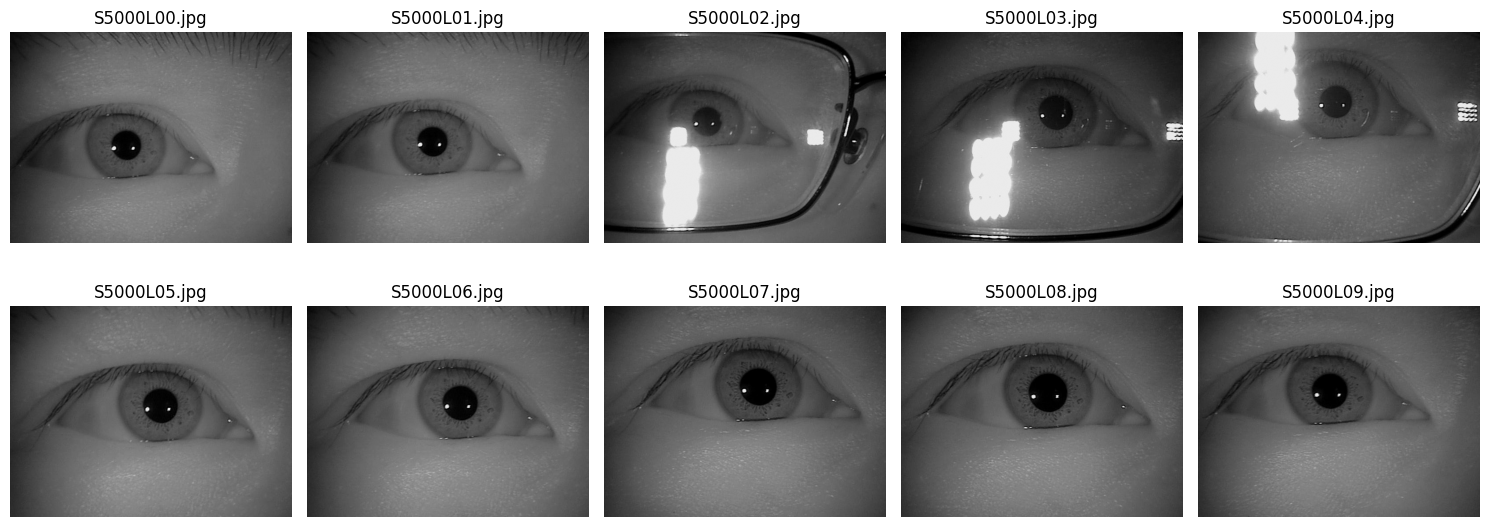

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick one subject and one eye
subject = "000"
eye = "L"

eye_folder = image_folder / subject / eye

# Get 10 images
image_paths = sorted(eye_folder.glob("*.jpg"))[:10]

plt.figure(figsize=(15, 6))

for i, image_path in enumerate(image_paths):
    img = Image.open(image_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
from collections import Counter
from PIL import Image

size_counts = Counter()

for subject in subjects:
    for eye in ["L", "R"]:
        eye_folder = subject / eye

        for image_path in eye_folder.glob("*.jpg"):
            with Image.open(image_path) as img:
                size_counts[img.size] += 1

print("Image size distribution:")
for size, count in size_counts.items():
    print(size, ":", count, "images")

Image size distribution:
(640, 480) : 20000 images


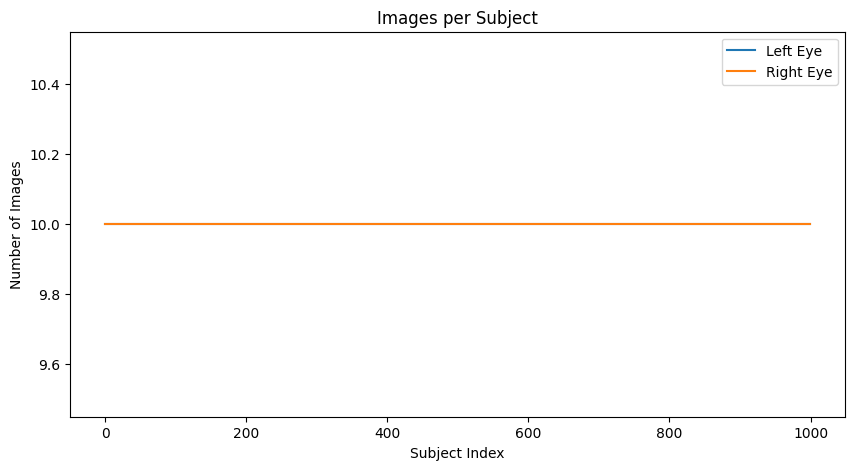

In [24]:
import matplotlib.pyplot as plt

left_counts = []
right_counts = []

for subject in subjects:
    left_count = len(list((subject / "L").glob("*.jpg")))
    right_count = len(list((subject / "R").glob("*.jpg")))

    left_counts.append(left_count)
    right_counts.append(right_count)

plt.figure(figsize=(10, 5))

plt.plot(left_counts, label="Left Eye")
plt.plot(right_counts, label="Right Eye")

plt.xlabel("Subject Index")
plt.ylabel("Number of Images")
plt.title("Images per Subject")
plt.legend()
plt.show()

In [25]:
import pandas as pd

csv_path = extract_path / "iris_thousands.csv"

df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

CSV shape: (20000, 3)

Columns:
['Unnamed: 0', 'Label', 'ImagePath']

First 5 rows:


,Unnamed: 0,Label,ImagePath
0,0,437-R,/kaggle/input/casia-iris-thousand/CASIA-Iris-T...
1,1,437-R,/kaggle/input/casia-iris-thousand/CASIA-Iris-T...
2,2,437-R,/kaggle/input/casia-iris-thousand/CASIA-Iris-T...
3,3,437-R,/kaggle/input/casia-iris-thousand/CASIA-Iris-T...
4,4,437-R,/kaggle/input/casia-iris-thousand/CASIA-Iris-T...


In [26]:
print("Number of unique labels:", df["Label"].nunique())

print("\nFirst 20 unique labels:")
print(df["Label"].unique()[:20])

Number of unique labels: 2000

First 20 unique labels:
['437-R' '437-L' '515-R' '515-L' '248-R' '248-L' '625-R' '625-L' '843-R'
 '843-L' '135-R' '135-L' '479-R' '479-L' '183-R' '183-L' '973-R' '973-L'
 '768-R' '768-L']


In [27]:
label_counts = df["Label"].value_counts()

print("Minimum images per label:", label_counts.min())
print("Maximum images per label:", label_counts.max())

print("\nNumber of labels with exactly 10 images:",
      (label_counts == 10).sum())

Minimum images per label: 10
Maximum images per label: 10

Number of labels with exactly 10 images: 2000


In [28]:
import os

total_size = 0

for subject in subjects:
    for eye in ["L", "R"]:
        eye_folder = subject / eye

        for image_path in eye_folder.glob("*.jpg"):
            total_size += image_path.stat().st_size

total_size_mb = total_size / (1024 ** 2)

print(f"Total image storage: {total_size_mb:.2f} MB")

Total image storage: 490.85 MB
